# Predicting National Park Crowd Levels Using Seasonal and Environmental Features

This project uses machine learning techniques to estimate National Park crowd levels based on historical visitation patterns, seasonal factors, and environmental conditions.

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
#split dataset into two: one to train model (80%) and other to evaluate performance (20%)
#from sklearn.model_selection import train_test_split

#used for classifciation
#from sklearn.linear_model import LogisticRegression
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.ensemble import RandomForestClassifier

In [13]:
import pandas as pd
df = pd.read_csv("data/Main_Data.csv")
df.head()

,UnitCode,Year,Month,Statistic,Value
0,ABLI,1979,1,TRV,1586
1,ABLI,1979,1,TNRV,0
2,ABLI,1979,1,TV,1586
3,ABLI,1979,1,TRVH,1586
4,ABLI,1979,1,TH,1586


In [25]:
visits_df = df[df["Statistic"] == "TRV"]
visits_df.shape

(193696, 5)

In [30]:
visits_df.head() 


,UnitCode,Year,Month,Statistic,Value
0,ABLI,1979,1,TRV,1586
15,ABLI,1979,2,TRV,3036
30,ABLI,1979,3,TRV,9853
45,ABLI,1979,4,TRV,33087
60,ABLI,1979,5,TRV,27838


In [31]:
visits_df["UnitCode"].unique()

array(['ABLI', 'FOCA', 'FLFO', 'BAND', 'ELRO', 'CRMO', 'SAFR', 'SITK',
       'PINN', 'SAJU', 'ASIS', 'ELMO', 'CABR', 'ORPI', 'EISE', 'AZRU',
       'SARA', 'CAHA', 'PIRO', 'DRTO', 'SACN', 'CAGR', 'ROLA', 'ROMO',
       'CONG', 'BOST', 'THIS', 'EUON', 'TAPR', 'ELMA', 'BUFF', 'BADL',
       'STRI', 'FOPO', 'KICA', 'WRBR', 'FOMA', 'WEFA', 'FODO', 'VIIS',
       'FOLS', 'THRI', 'VAMA', 'FOSC', 'HAFO', 'GEWA', 'HEHO', 'FOUN',
       'GRPO', 'GREE', 'ACAD', 'HALE', 'HUTR', 'FOSU', 'KLSE', 'HOFU',
       'GWCA', 'CAVO', 'KALA', 'FORA', 'GRSA', 'EDIS', 'GEGR', 'FOVA',
       'KEMO', 'GERO', 'EVER', 'FOBU', 'LABE', 'HOBE', 'KIMO', 'FOMC',
       'FRLA', 'JOFL', 'WICA', 'MIMA', 'HOFR', 'MOJA', 'NAVA', 'MOCR',
       'GRBA', 'FONE', 'GETT', 'ROCR', 'LEWI', 'NATC', 'NABR', 'DAAV',
       'PAIS', 'CEBR', 'OCMU', 'CACL', 'PECO', 'VOYA', 'KNRI', 'ADAM',
       'JODR', 'KOVA', 'PORE', 'OBRI', 'MALU', 'JEFF', 'BEOL', 'SUCR',
       'YELL', 'FIIS', 'BLCA', 'TUIN', 'WOTR', 'GUIS', 'LYJO', 'LIBO',
      

In [32]:
#num of unique parks
visits_df["UnitCode"].nunique()

406

In [36]:
visits_df["Year"].min()


1979

In [35]:
visits_df["Year"].max()

2025

In [40]:
#records per park
visits_df["UnitCode"].value_counts()

UnitCode
ABLI    564
LIBI    564
MORA    564
DENA    564
MANA    564
       ... 
STGE     24
IATR     24
TILL     24
APPA     12
HART     12
Name: count, Length: 406, dtype: int64

In [41]:
visits_df["UnitCode"].value_counts().describe()

count    406.000000
mean     477.083744
std      157.867198
min       12.000000
25%      456.000000
50%      564.000000
75%      564.000000
max      564.000000
Name: count, dtype: float64

In [42]:
visits_df.isnull().sum()

UnitCode     0
Year         0
Month        0
Statistic    0
Value        0
dtype: int64

In [43]:
visits_df["Value"].describe()

count    1.936960e+05
mean     6.778093e+04
std      1.693893e+05
min     -2.033100e+04
25%      2.845000e+03
50%      1.262500e+04
75%      5.530925e+04
max      3.912215e+06
Name: Value, dtype: float64

In [44]:
visits_df[visits_df["Value"] < 0]

,UnitCode,Year,Month,Statistic,Value
115165,SAJH,2002,11,TRV,-20331
119550,MORR,2011,12,TRV,-320
1614450,LIBO,2003,1,TRV,-425
1731905,RUCA,2004,11,TRV,-39


In [46]:
visits_df = visits_df[visits_df["Value"] >= 0]
visits_df.shape

(193692, 5)

In [47]:
visits_df["Value"].min()

0

In [49]:
monthly_avg = visits_df.groupby("Month")["Value"].mean()
monthly_avg

Month
1      31683.631670
2      33785.742749
3      50633.682449
4      64102.844405
5      78311.294734
6      97754.019330
7     119058.947597
8     108246.257309
9      79737.622979
10     68406.662124
11     45949.272361
12     35679.840374
Name: Value, dtype: float64

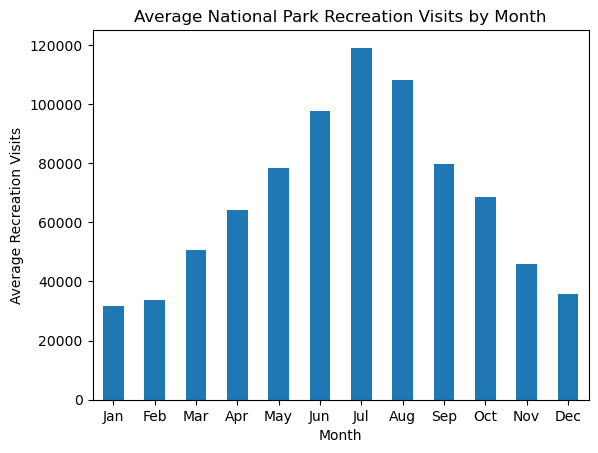

In [57]:
monthly_avg.plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Average Recreation Visits")
plt.title("Average National Park Recreation Visits by Month")

plt.xticks(
    range(12),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=0
)

plt.show()